# Low pass filtering

As specified on the datasheet and register map, the MPU6050 has a built-in digital low pass filter. It's helpful because it provides some smoothing, noise reduction and anti-aliasing at zero computational cost on the microcontroller. On the other hand, it introduces a delay/phase shift in the signal, getting worse with lower cutoff frequencies. Unfortunately, the exact characteristics of the filter are not specified. Instead, only the cutoff frequency can be configured by setting the DLPF_CFG bits in the CONFIG register (26). Available frequencies are: 

| DLPF_CFG | Accel Bandwidth (Hz) | Delay (ms) | Gyro Bandwidth (Hz) | Delay (ms) | Fs (kHz) |
|----------|---------------------|------------|----------------------|------------|-----|
| 0 | 256 | 0.98 | 260 | 0.98 | 8 |
| 1 | 188 | 1.9  | 184 | 2.0  | 1 |
| 2 | 98  | 2.8  | 94  | 3.0  | 1 |
| **3** | **42**  | **4.8**  | **44**  | **4.9**  | **1** |
| 4 | 20  | 8.3  | 21  | 8.5  | 1 |
| 5 | 10  | 13.4 | 10  | 13.8 | 1 |
| 6 | 5   | 18.6 | 5   | 19.0 | 1 |
| 7 | RESERVED | RESERVED | RESERVED | RESERVED | 8 |

Other filter characteristics like the order, the type, or the presence of passband ripple or ringing are not specified. It's assumed that it's a digital low order IIR (infinite-impulse response) filter. I think this because the sensor was/is designed to be low power and low cost, and otherwise Invensense would have leveraged the filter characteristics as a selling point.

Based on a brief research and common sense, most common human movements fall comfortably below 10-20Hz, but since device will be used for high speed/power movements and there may be impacts, vibration or resonance, a margin of safety is needed. Additionally, according to the sampling theorem, the sampling frequency should be at least twice the highest frequency of interest to avoid aliasing. Based on this, 42/44Hz seems like a good first choice, trying to match it with a sampling frequency of at least 100Hz ideally. 

To avoid overengineering, initially I thought of just using this built-in filter, but additional filtering is needed since I have seen downstream that velocity is very sensitive to noise. A fast software low pass filter like the moving average filter (which is a FIR, finite impulse response) is tested with different kernel lengths to find a good compromise between noise reduction, responsiveness, and signal sharpness. While performing a convolution with a rectangular kernel with odd length is effective and symmetric/linear phase, it produces awkard behavior (and problems downstream) on the edges due to padding/incomplete convolution. Since on the device it would be implemented as a causal, sliding window anyway, I chose this approach directly here to avoid the aforementioned problem. In both cases, it reduces noise proportional to $\sqrt{k}$, where $k$ is the kernel length.  

Notice that the alternative on the time domain, a single pole IIR filter, while it requires a similar programming effort than the moving average (minimal), it has a non-linear phase response, which can distort the signal by introducing non-constant delays, and to make it zero-phase two passes of filtering are needed (one forwards and one backwards), which is not possible for the decided streaming, real-time architecture. Because of this reason, it will not be used. Also notice that frequency domain filtering, while it can provide a decent signal smoothing, creates a Gibbs-like effect on the signal, which is unacceptable for this application.  

Resources:
* https://valdperformance.com/news/sampling-frequency-how-much-is-enough
* [The scientist and engineer's guide to digital signal processing, Steven W. Smith - Chapters 3, 15, 19, 21](../../docs/misc/The%20Scientist%20and%20Engineers%20Guide%20to%20Digital%20signal%20processing%20-%20Steven%20W.%20Smith.pdf)
* https://www.youtube.com/watch?v=t3fCbQCSeQs
* [MPU6050 datasheet](../../docs/misc/MPU6050%20datasheet.pdf)
* [MPU6050 register map](../../docs/misc/MPU6050%20registers.pdf)



## Setup

In [175]:
from signal_utils import (
    IMUSampleReader,
    IMUSampleWriter,
    IMUStationaryChecker,
)
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

sixFaceStationaryCaptures = [
    "../1-calibration/output/pos-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-z-up-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-z-up-calib-affine-sixf-tilted-a-online-w.csv",
]
tiltedStationaryCaptures = [
    "../1-calibration/output/pos-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-pos-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-x-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pos-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/neg-y-neg-z-tilt-calib-affine-sixf-tilted-a-online-w.csv",
]

simpleRotationsCaptures = [
    "../1-calibration/output/rot-x-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-y-hw-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/rot-z-hw-calib-affine-sixf-tilted-a-online-w.csv",
]

realExerciseCaptures = [
    "../1-calibration/output/dips-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/dips-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/pull-ups-3-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-1-calib-affine-sixf-tilted-a-online-w.csv",
    "../1-calibration/output/90-deg-push-ups-2-calib-affine-sixf-tilted-a-online-w.csv",
]

reader = IMUSampleReader()
writer = IMUSampleWriter()
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(
    [*sixFaceStationaryCaptures, *tiltedStationaryCaptures]
)


def plotFilteredSignal(capture, lowerP, upperP, kernelLengths):
    colors = [
        "red",
        "green",
        "blue",
        "cyan",
        "orange",
        "purple",
        "brown",
        "pink",
        "gray",
        "olive",
        "cyan",
    ]
    if len(kernelLengths) > len(colors) - 1:
        raise ValueError(
            f"Too many kernel lengths ({len(kernelLengths)}) for available colors ({len(colors) - 1})"
        )

    fig, axes = plt.subplots(2, 1, figsize=(20, 10))

    seq, a, w = reader.readRaw(capture)
    aNorm = np.linalg.norm(a, axis=1)
    wNorm = np.linalg.norm(w, axis=1)

    axes[0].set_title("Accelerometer")
    axes[0].set_xlabel("Sequence number")
    axes[0].set_ylabel("Norm (m/s²)")
    axes[0].grid()

    axes[1].set_title("Gyroscope")
    axes[1].set_xlabel("Sequence number")
    axes[1].set_ylabel("Norm (deg/s)")
    axes[1].grid()

    axes[0].plot(aNorm, label="Original", color=colors[0])
    axes[1].plot(wNorm, label="Original", color=colors[0])

    # Upper and lower vertical limits
    axes[0].set_ylim(np.percentile(aNorm, lowerP), np.percentile(aNorm, upperP))
    axes[1].set_ylim(np.percentile(wNorm, lowerP), np.percentile(wNorm, upperP))

    # Stationary bands
    aNormLow = stationaryChecker.accelMean - stationaryChecker.accelTol
    aNormHigh = stationaryChecker.accelMean + stationaryChecker.accelTol
    axes[0].axhspan(
        aNormLow, aNormHigh, color="grey", alpha=0.25, label="Stationary band"
    )

    wNormLow = stationaryChecker.gyroMean - stationaryChecker.gyroTol
    wNormHigh = stationaryChecker.gyroMean + stationaryChecker.gyroTol
    axes[1].axhspan(wNormLow, wNormHigh, color="grey", alpha=0.25)

    for j, kLen in enumerate(kernelLengths):
        aFiltered = filterMovingAverage(a, kLen)
        wFiltered = filterMovingAverage(w, kLen)

        aNorm = np.linalg.norm(aFiltered, axis=1)
        wNorm = np.linalg.norm(wFiltered, axis=1)

        axes[0].plot(
            aNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[1].plot(
            wNorm,
            label=f"k={kLen}",
            color=colors[1 + j],
        )
        axes[0].legend()
        axes[1].legend()

    fig.tight_layout()
    plt.show()


def filterMovingAverage(x, k):
    return filterStreamingMovingAverage(x, k)


def filterConvolutionMovingAverage(x, k):
    kernel = np.ones(k) / k
    return np.array(
        [sp.signal.convolve(x[:, j], kernel) for j in range(x.shape[1])],
        dtype=np.float64,
    ).T


def filterStreamingMovingAverage(x, k):
    sumWindow = np.zeros(x.shape[1], dtype=np.float64)
    result = np.zeros_like(x, dtype=np.float64)
    for i in range(x.shape[0]):
        sumWindow += x[i, :]
        if i >= k:
            sumWindow -= x[i - k, :]
            windowLen = k
        else:
            windowLen = i + 1
        result[i, :] = sumWindow / windowLen

    return result

Acceleration norms:
	Mean = 9.803800
	Stdev = 0.080243
	Interval = [9.563072, 10.044527]
Gyroscope norms:
	Mean = 0.171970
	Stdev = 1.717855
	Interval = [-4.981595, 5.325534]


## Graphical inspection

The norm instead of each axis is plotted to simplify the inspection.

Bigger kernels may make the signal move away from an imagined noise-free, least-squares fitted signal in some isolated cases. Some amplitude is lost. Sharpness is not compromised too much. Bigger kernels introduce a noticeable phase shift. A kernel of more than about 15 samples seems unnecessary.

Being careful of the scale of the graphs, the accelerometer and gyroscope may have different noise reduction needs. However, using different kernel sizes for each sensor may be a bad idea, since that will introduce two different delays in the signals and alter orientation downstream. A compromise is needed.

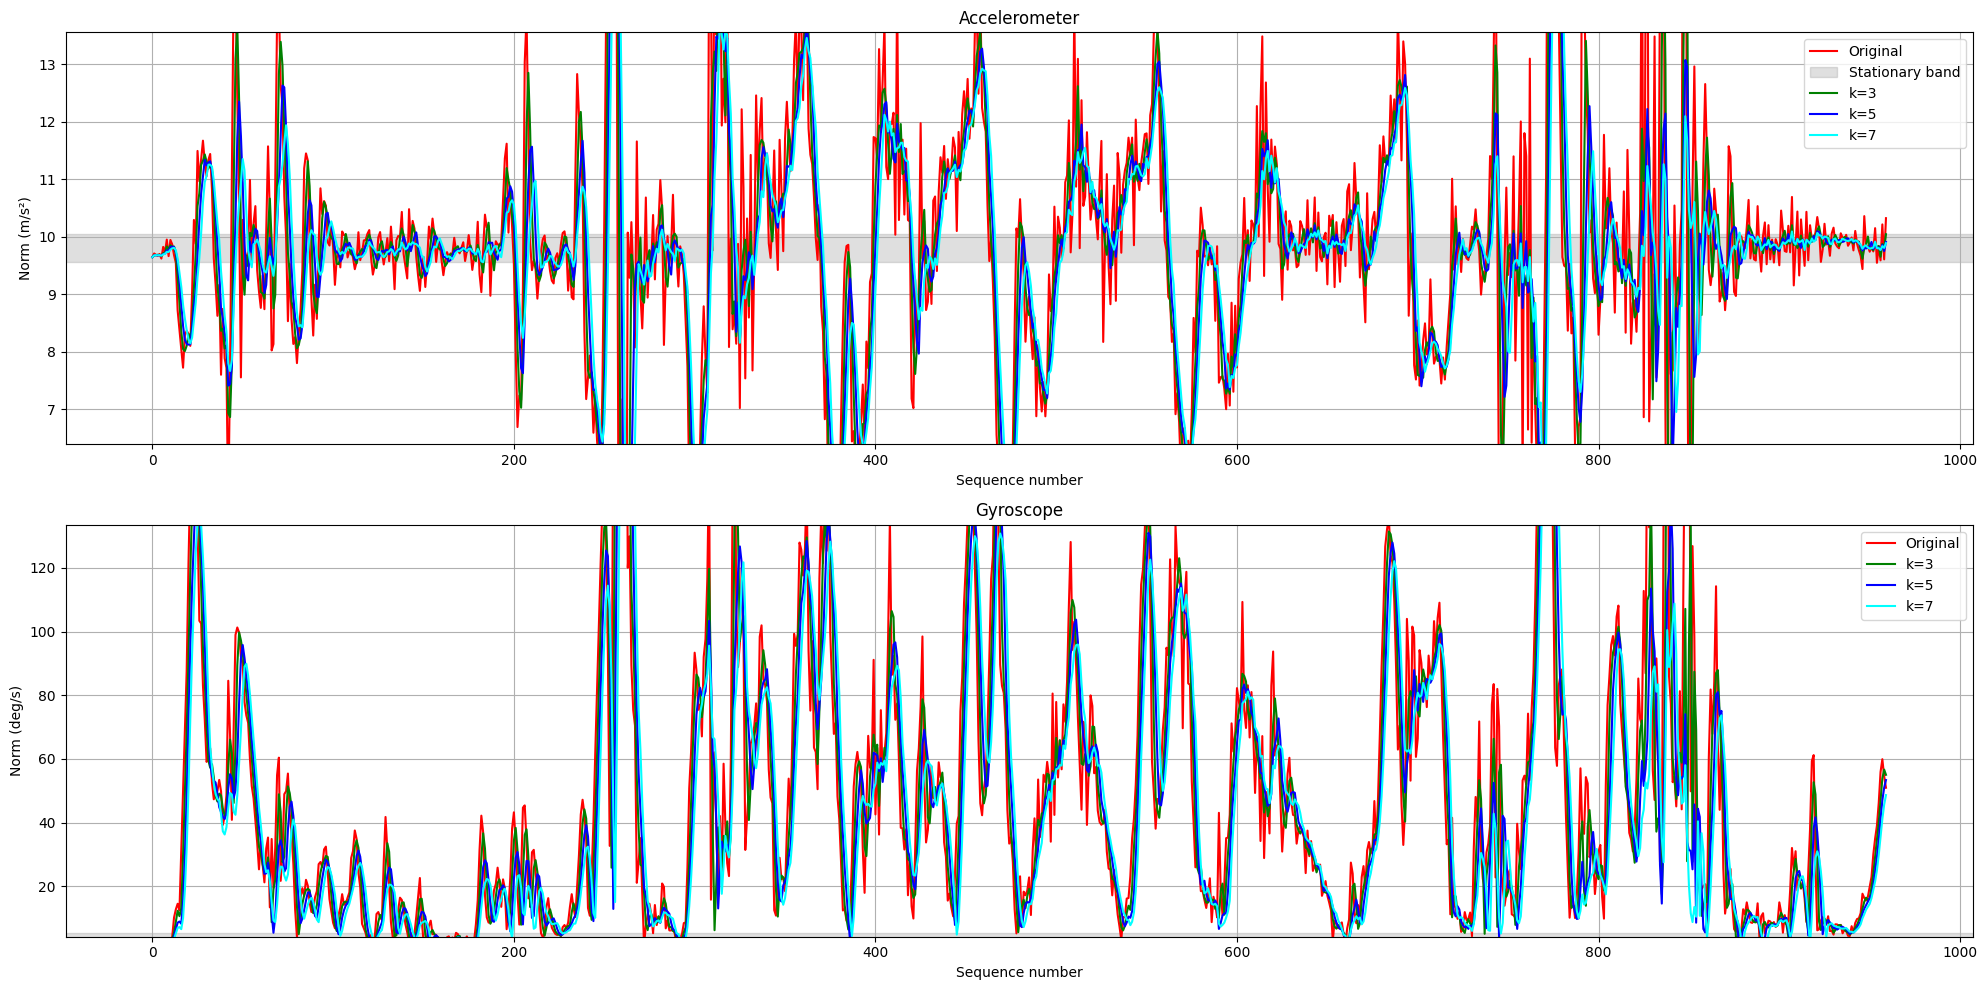

In [176]:
# CHOSEN_CAPTURE = sixFaceStationaryCaptures[0]
# CHOSEN_CAPTURE = tiltedStationaryCaptures[0]
# CHOSEN_CAPTURE = simpleRotationsCaptures[0]
CHOSEN_CAPTURE = realExerciseCaptures[6]
smallKernels = [3, 5, 7]
plotFilteredSignal(CHOSEN_CAPTURE, 5, 95, smallKernels)

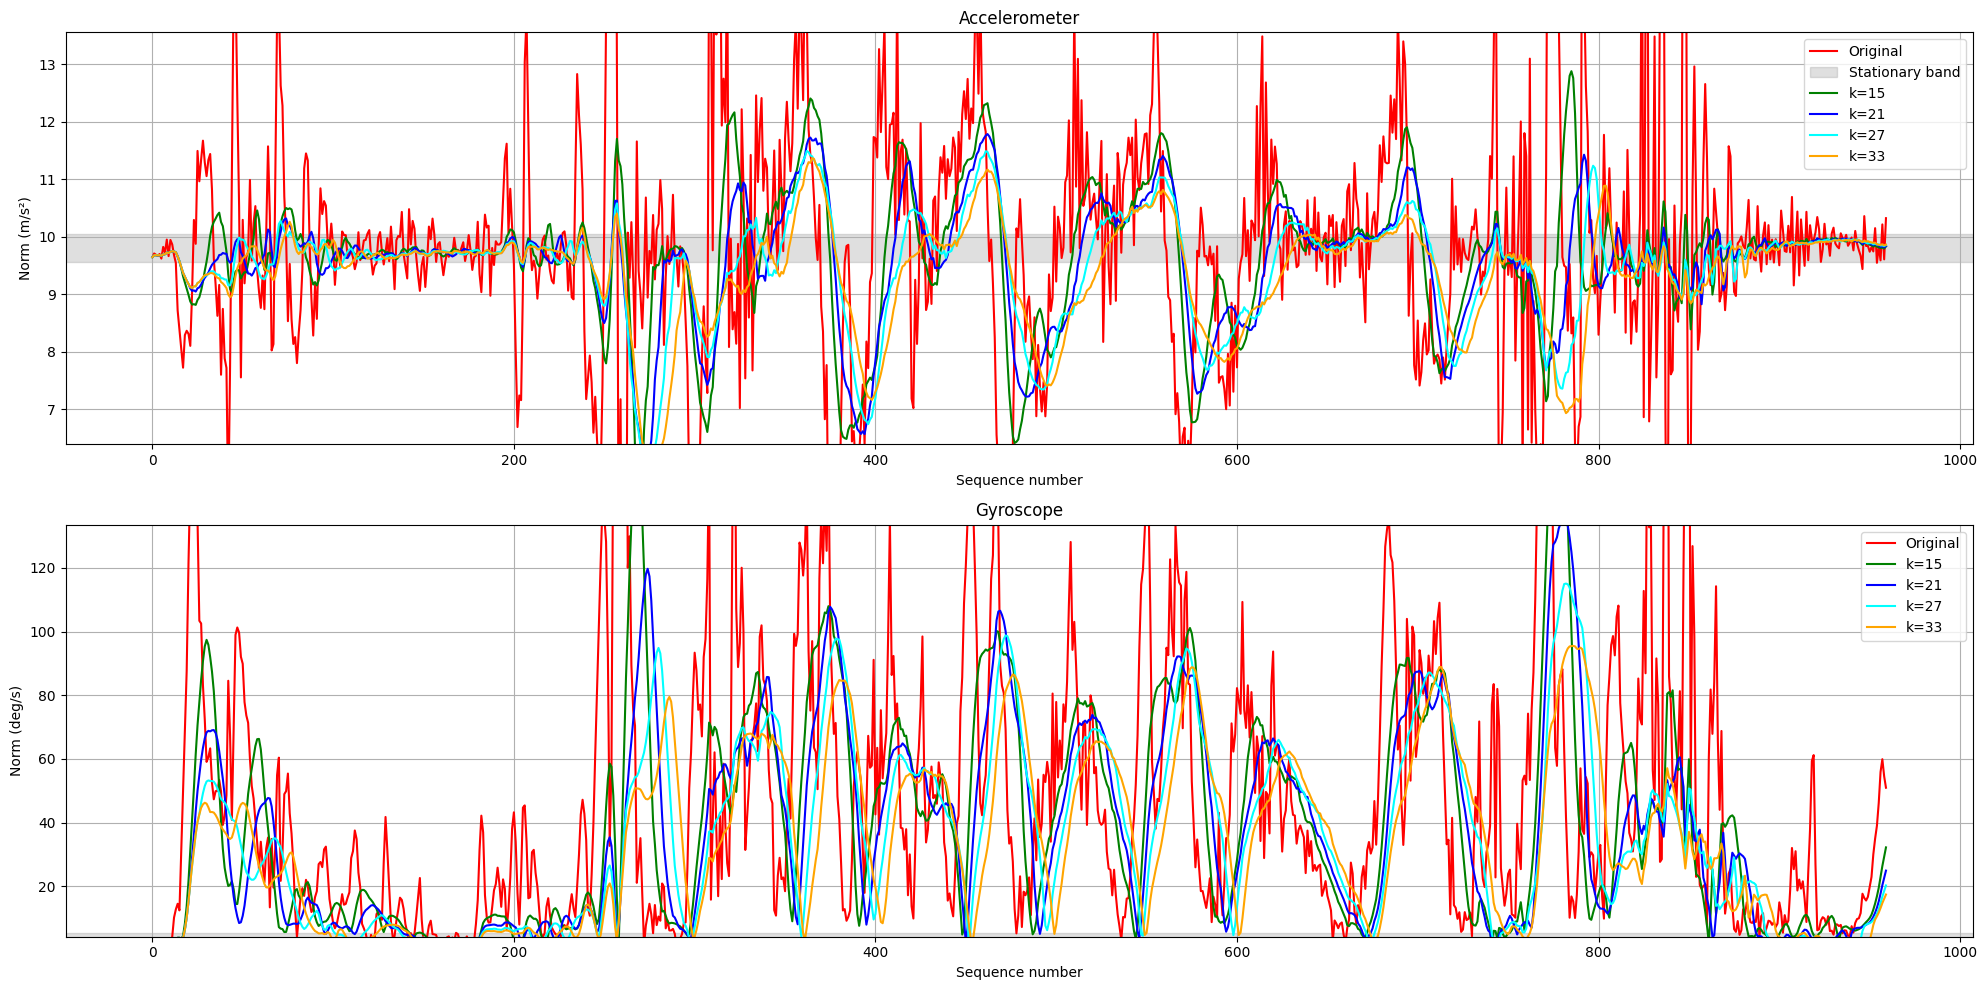

In [177]:
bigKernels = [15, 21, 27, 33]
plotFilteredSignal(CHOSEN_CAPTURE, 5, 95, bigKernels)

## Numerical inspection

The standard deviation of stationary intervals is a simple (but not perfect) proxy for noise. A relatively low value is preferred.

As pointed out earlier, performance gains are modest in general but more so with bigger kernels.

In [178]:
def computeFilteredSummaryMetrics(captures):
    print(f"Summary metrics for stationary captures before and after filtering:")

    aRawNorms = []
    wRawNorms = []
    memo = {}
    for capture in captures:
        memo[capture] = reader.readRaw(capture)
        _, a, w = memo[capture]
        stationaryFlags = stationaryChecker.areStationarySamples(a, w)
        aNorm = np.linalg.norm(a[stationaryFlags], axis=1)
        wNorm = np.linalg.norm(w[stationaryFlags], axis=1)
        aRawNorms.append(aNorm)
        wRawNorms.append(wNorm)
    aRawNorms = np.concatenate(aRawNorms)
    wRawNorms = np.concatenate(wRawNorms)

    aRawMean = np.mean(aRawNorms)
    aRawStd = np.std(aRawNorms)
    wRawMean = np.mean(wRawNorms)
    wRawStd = np.std(wRawNorms)
    print(
        f"k = 0 (raw):"
        f"\n\tAccel: mean={aRawMean:.6f} std={aRawStd:.6f}"
        f"\n\tGyro: mean={wRawMean:.6f} std={wRawStd:.6f}"
    )

    for kLen in [*smallKernels, *bigKernels]:
        aFilteredNorms = []
        wFilteredNorms = []
        for capture in captures:
            _, a, w = memo[capture]
            aFiltered = filterMovingAverage(a, kLen)
            wFiltered = filterMovingAverage(w, kLen)
            stationaryFlags = stationaryChecker.areStationarySamples(
                aFiltered, wFiltered
            )
            aNorm = np.linalg.norm(aFiltered[stationaryFlags], axis=1)
            wNorm = np.linalg.norm(wFiltered[stationaryFlags], axis=1)
            aFilteredNorms.append(aNorm)
            wFilteredNorms.append(wNorm)
        aFilteredNorms = np.concatenate(aFilteredNorms)
        wFilteredNorms = np.concatenate(wFilteredNorms)

        print(
            f"k={kLen}:"
            f"\n\tAccel: \tmeanDiff={aRawMean - np.mean(aFilteredNorms):.6f} \tstdDiff={aRawStd - np.std(aFilteredNorms):.6f}"
            f"\n\tGyro: \tmeanDiff={wRawMean - np.mean(wFilteredNorms):.6f} \tstdDiff={wRawStd - np.std(wFilteredNorms):.6f}"
        )

### Stationary captures

In [179]:
computeFilteredSummaryMetrics([*sixFaceStationaryCaptures, *tiltedStationaryCaptures])

Summary metrics for stationary captures before and after filtering:
k = 0 (raw):
	Accel: mean=9.803766 std=0.079637
	Gyro: mean=0.102710 std=0.274605
k=3:
	Accel: 	meanDiff=0.000295 	stdDiff=0.000711
	Gyro: 	meanDiff=0.023182 	stdDiff=0.008461
k=5:
	Accel: 	meanDiff=0.000389 	stdDiff=0.000948
	Gyro: 	meanDiff=0.032484 	stdDiff=0.032412
k=7:
	Accel: 	meanDiff=0.000475 	stdDiff=0.001023
	Gyro: 	meanDiff=0.037689 	stdDiff=0.043430
k=15:
	Accel: 	meanDiff=0.000604 	stdDiff=0.001086
	Gyro: 	meanDiff=0.041017 	stdDiff=-0.000267
k=21:
	Accel: 	meanDiff=0.000527 	stdDiff=0.001107
	Gyro: 	meanDiff=0.033697 	stdDiff=-0.048520
k=27:
	Accel: 	meanDiff=0.000525 	stdDiff=0.001112
	Gyro: 	meanDiff=0.030673 	stdDiff=-0.062643
k=33:
	Accel: 	meanDiff=0.000537 	stdDiff=0.001115
	Gyro: 	meanDiff=0.028700 	stdDiff=-0.066389


### Simple rotations captures

In [180]:
computeFilteredSummaryMetrics(simpleRotationsCaptures)

Summary metrics for stationary captures before and after filtering:
k = 0 (raw):
	Accel: mean=9.905658 std=0.066082
	Gyro: mean=1.294100 std=1.202752
k=3:
	Accel: 	meanDiff=-0.003716 	stdDiff=0.010348
	Gyro: 	meanDiff=0.125469 	stdDiff=0.024603
k=5:
	Accel: 	meanDiff=-0.004687 	stdDiff=0.015184
	Gyro: 	meanDiff=0.171005 	stdDiff=0.016428
k=7:
	Accel: 	meanDiff=-0.005154 	stdDiff=0.017439
	Gyro: 	meanDiff=0.220077 	stdDiff=0.043010
k=15:
	Accel: 	meanDiff=-0.005029 	stdDiff=0.019034
	Gyro: 	meanDiff=0.311918 	stdDiff=0.050665
k=21:
	Accel: 	meanDiff=-0.005021 	stdDiff=0.019752
	Gyro: 	meanDiff=0.379211 	stdDiff=0.099498
k=27:
	Accel: 	meanDiff=-0.004831 	stdDiff=0.020098
	Gyro: 	meanDiff=0.412866 	stdDiff=0.105080
k=33:
	Accel: 	meanDiff=-0.004427 	stdDiff=0.020140
	Gyro: 	meanDiff=0.415447 	stdDiff=0.080085


### Real exercise captures

In [181]:
computeFilteredSummaryMetrics(realExerciseCaptures)

Summary metrics for stationary captures before and after filtering:


k = 0 (raw):
	Accel: mean=9.852055 std=0.124279
	Gyro: mean=3.201039 std=1.285256
k=3:
	Accel: 	meanDiff=-0.005293 	stdDiff=0.010415
	Gyro: 	meanDiff=0.069827 	stdDiff=0.038131
k=5:
	Accel: 	meanDiff=-0.008612 	stdDiff=0.018758
	Gyro: 	meanDiff=0.131782 	stdDiff=0.044974
k=7:
	Accel: 	meanDiff=-0.000853 	stdDiff=0.018536
	Gyro: 	meanDiff=0.047093 	stdDiff=0.043187
k=15:
	Accel: 	meanDiff=0.001100 	stdDiff=0.024926
	Gyro: 	meanDiff=0.074171 	stdDiff=0.065725
k=21:
	Accel: 	meanDiff=0.002363 	stdDiff=0.033597
	Gyro: 	meanDiff=0.033979 	stdDiff=0.048557
k=27:
	Accel: 	meanDiff=0.011246 	stdDiff=0.032815
	Gyro: 	meanDiff=0.130332 	stdDiff=0.076678
k=33:
	Accel: 	meanDiff=0.018465 	stdDiff=0.032315
	Gyro: 	meanDiff=0.063144 	stdDiff=0.062795


## Conclusion

A kernel of $k = 5$ paired with the built-in filter (not present in exported results) should provide a good degree of noise reduction without compromising too much the signal sharpness and responsiveness.

In [182]:
CHOSEN_KERNEL_LEN = 5


def exportResults(captures):
    for capture in captures:
        seq, a, w = reader.readRaw(capture)
        aFiltered = filterMovingAverage(a, CHOSEN_KERNEL_LEN)
        wFiltered = filterMovingAverage(w, CHOSEN_KERNEL_LEN)

        oldFileName = capture.split("/")[-1].split(".")[0]
        writer.writeRaw(
            f"./output/{oldFileName}-filt-box5.csv", seq, aFiltered, wFiltered
        )


exportResults([*sixFaceStationaryCaptures, *tiltedStationaryCaptures])
exportResults(simpleRotationsCaptures)
exportResults(realExerciseCaptures)